# Analiza podatkov za smučarske skoke (2012-2026)

Analizirali bomo podatke o državah in skakalcih, ki tekmujejo ali so tekmovali v smučarskih skokih med letoma 2012 in 2026.


In [2]:
import pandas as pd  

## Uvod
Za začetek si poglejmo kako izgleda naša tabela za analizo podatkov

In [5]:
moski = pd.read_csv("../skoki_moski.csv", index_col="Ime")
moski.head(85)

,DrzavaID,Zlato,Srebro,Bron,Skupaj
Ime,,,,,
Stefan Kraft,AUT,46,37,39,122
Ryōyū Kobayashi,JPN,37,27,20,84
Kamil Stoch,POL,33,17,18,68
Andreas Wellinger,GER,12,24,16,52
Domen Prevc,SLO,28,13,10,51
...,...,...,...,...,...
Clemens Aigner,AUT,0,0,1,1
Paweł Wąsek,POL,0,0,1,1
Jonas Schuster,AUT,0,0,1,1


Analizirali bomo koliko medalj so moški posebej prispevali k skupnemu seštevku medalj skozi vse sezone.


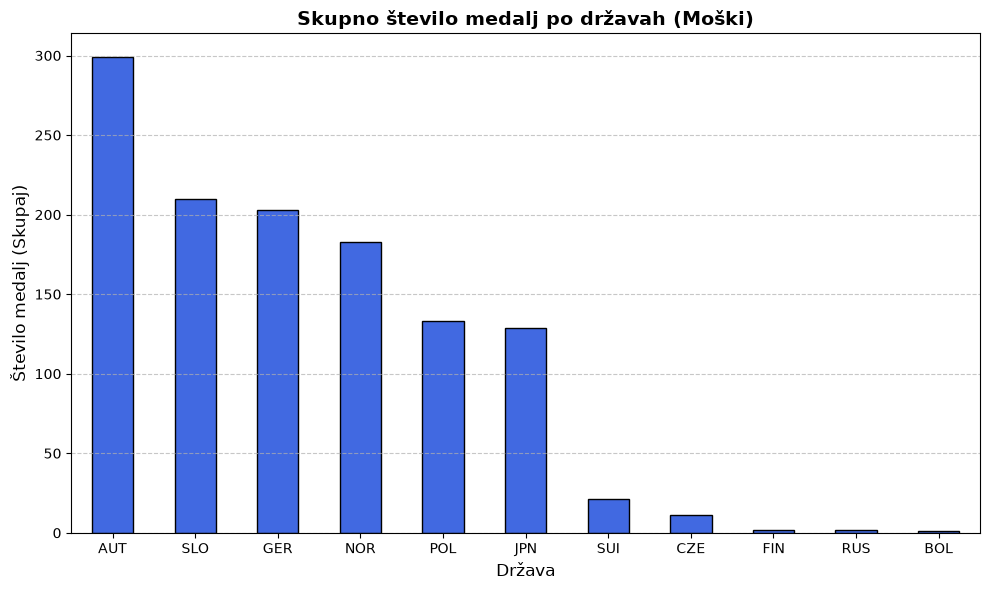

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prenos podatkov iz CSV datoteke
# (Prilagodi pot do datoteke, če se ne nahaja v isti mapi)
df = pd.read_csv("../skoki_moski.csv")

# 2. Združevanje podatkov po državah in seštevek vseh medalj ("Skupaj")
# Uporabimo .groupby() in izberemo stolpec 'Skupaj'
medalje_po_drzavah = df.groupby("DrzavaID")["Skupaj"].sum().sort_values(ascending=False)

# 3. Izris stolpičnega grafa
plt.figure(figsize=(10, 6))
medalje_po_drzavah.plot(kind="bar", color="royalblue", edgecolor="black")

# Dodajanje naslova in oznak osi
plt.title(
    "Skupno število medalj po državah (Moški)", fontsize=14, fontweight="bold"
)
plt.xlabel("Država", fontsize=12)
plt.ylabel("Število medalj (Skupaj)", fontsize=12)

# Rotacija oznak na X osi, da so lepše berljive
plt.xticks(rotation=0)

# Dodajanje mreže za lažje branje grafa
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Prikaz grafa
plt.tight_layout()
plt.show()


Zdaj še isto ponovimo za ženske.

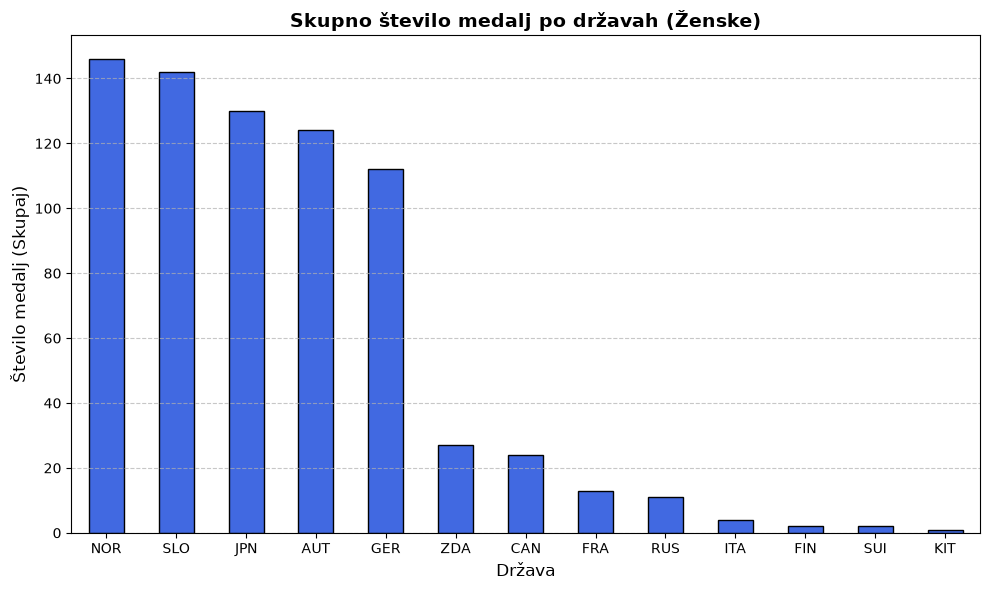

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prenos podatkov iz CSV datoteke
# (Prilagodi pot do datoteke, če se ne nahaja v isti mapi)
df = pd.read_csv("../skoki_zenske.csv")

# 2. Združevanje podatkov po državah in seštevek vseh medalj ("Skupaj")
# Uporabimo .groupby() in izberemo stolpec 'Skupaj'
medalje_po_drzavah = df.groupby("DrzavaID")["Skupaj"].sum().sort_values(ascending=False)

# 3. Izris stolpičnega grafa
plt.figure(figsize=(10, 6))
medalje_po_drzavah.plot(kind="bar", color="royalblue", edgecolor="black")

# Dodajanje naslova in oznak osi
plt.title(
    "Skupno število medalj po državah (Ženske)", fontsize=14, fontweight="bold"
)
plt.xlabel("Država", fontsize=12)
plt.ylabel("Število medalj (Skupaj)", fontsize=12)

# Rotacija oznak na X osi, da so lepše berljive
plt.xticks(rotation=0)

# Dodajanje mreže za lažje branje grafa
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Prikaz grafa
plt.tight_layout()
plt.show()


Ker so v obeh grafih velike številke glede na vse sezone analizirajmo še glede na vsako sezono posamezno, da vidimo kako se je število medalj z vsako sezono povečevalo.

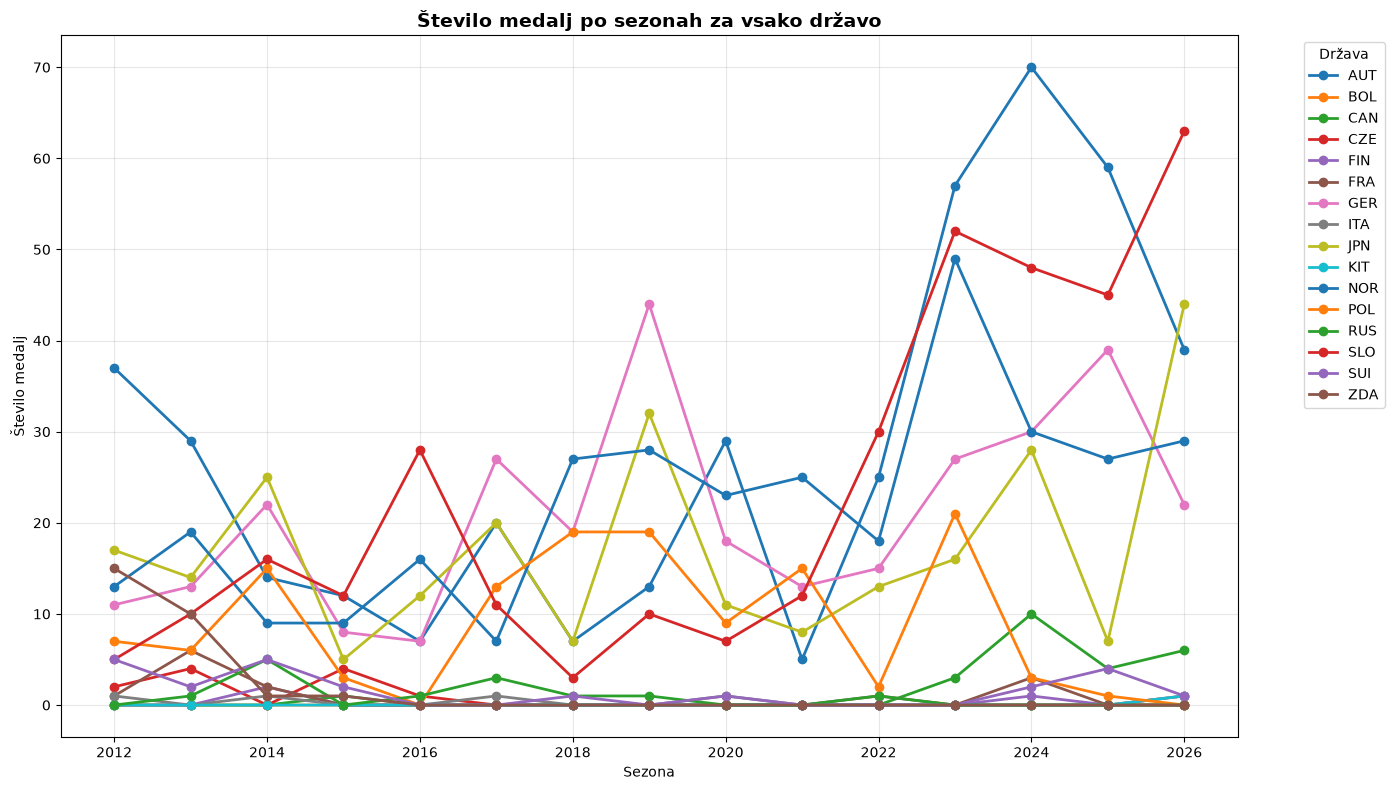

In [ ]:
import glob
import os
import matplotlib.pyplot as plt
import pandas as pd

# 1) Uvoz vseh CSV datotek
poti = sorted(glob.glob("../sezone_drzave/medalje_drzave_*.csv"))
vsi = []

for pot in poti:
    df = pd.read_csv(pot)
    leto = int(os.path.basename(pot).split("_")[-1].replace(".csv", ""))
    df["Sezona"] = leto
    vsi.append(df)

skupni = pd.concat(vsi, ignore_index=True)

# 2) Pivot tabela: vrstice = sezone, stolpci = države
tabela = skupni.pivot(index="Sezona", columns="DrzavaID", values="Skupaj").fillna(0)

# 3) Izris veččrtnega grafa
plt.figure(figsize=(14, 8))

for drzava in tabela.columns:
    plt.plot(tabela.index, tabela[drzava], marker="o", linewidth=2, label=drzava)

plt.title("Število medalj po sezonah za vsako državo", fontsize=14, fontweight="bold")
plt.xlabel("Sezona")
plt.ylabel("Število medalj")
plt.grid(True, alpha=0.3)
plt.legend(title="Država", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


Za boljšo predstavo te 3D grafa naredimo še tabelo.

In [ ]:
import glob
import os
import pandas as pd

# 1. Poišči vse CSV datoteke v mapi 'sezone_drzave'
poti_do_datotek = sorted(glob.glob("../sezone_drzave/medalje_drzave_*.csv"))

vsi_podatki = []

# 2. Preberi vsako datoteko in ji dodaj stolpec za Sezono
for pot in poti_do_datotek:
    df = pd.read_csv(pot)

    # Izlušči leto iz imena datoteke
    ime_datoteke = os.path.basename(pot)
    leto = int(ime_datoteke.split("_")[-1].replace(".csv", ""))

    df["Sezona"] = leto
    vsi_podatki.append(df)

# Združimo vse sezone v en velik DataFrame
skupni_df = pd.concat(vsi_podatki, ignore_index=True)

# 3. Ustvarimo veliko tabelo (Pivot Table)
# Sezone bodo vrstice, države bodo stolpci, vrednosti pa vsota medalj
velika_tabela = skupni_df.pivot_table(
    index="Sezona", columns="DrzavaID", values="Skupaj", aggfunc="sum"
).fillna(0)

# Spremenimo tipe podatkov v cela števila (da ni npr. 15.0)
velika_tabela = velika_tabela.astype(int)

# 4. Dodamo vrstico s skupno vsoto za vsako državo na dno tabele
velika_tabela.loc["SKUPAJ VSOTA"] = velika_tabela.sum()

# Prikaz celotne tabele
print(velika_tabela)

DrzavaID      AUT  BOL  CAN  CZE  FIN  FRA  GER  ITA  JPN  KIT  NOR  POL  RUS  \
Sezona                                                                          
2012           37    0    0    2    0    1   11    1   17    0   13    7    0   
2013           29    0    0    4    0    6   13    0   14    0   19    6    1   
2014           14    0    0    0    2    2   22    1   25    0    9   15    5   
2015           12    0    1    4    0    0    8    0    5    0    9    3    0   
2016            7    0    0    1    0    0    7    0   12    0   16    0    1   
2017           20    0    0    0    0    0   27    1   20    0    7   13    3   
2018            7    0    0    0    0    0   19    0    7    0   27   19    1   
2019           13    0    0    0    0    0   44    0   32    0   28   19    1   
2020           29    0    0    0    0    0   18    1   11    0   23    9    0   
2021            5    0    0    0    0    0   13    0    8    0   25   15    0   
2022           25    0    0 

Za zaključek analize si izberimo eno državo in ji posebej analiziramo kateri skakalci so pripomogli najbolj k najboljšim rezultatom. Odločili smo se za Slovenijo, saj je to zadnjo sezono dosegla enega izmed najboljših dosežkov do zdaj.

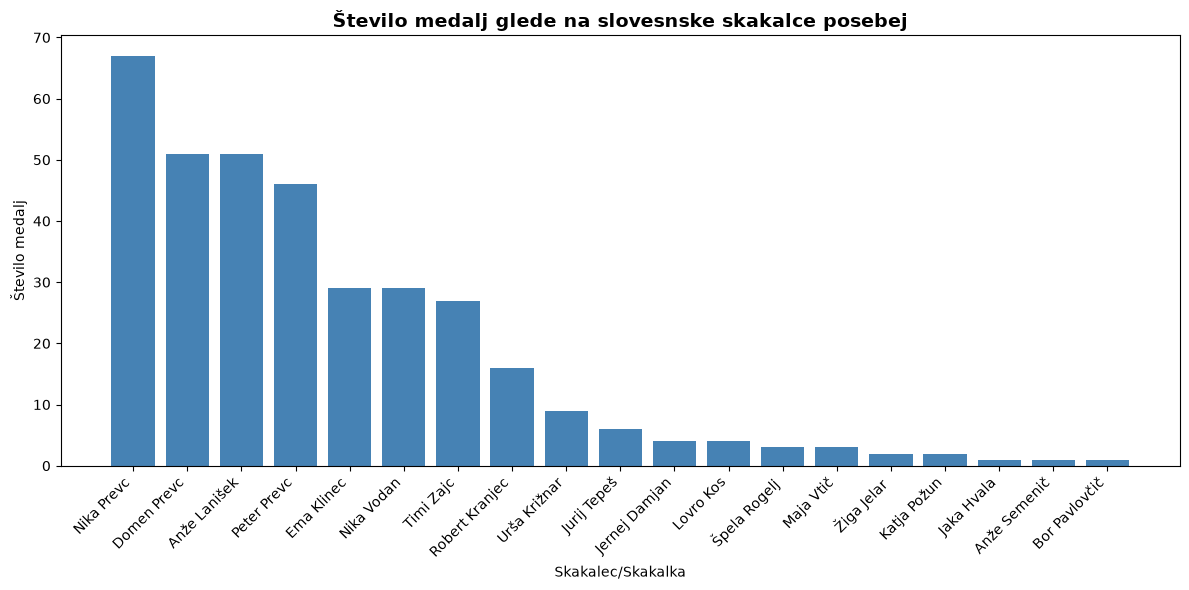

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Uvoz tabele iz vprašanja
df = pd.read_csv("../skoki_skupno.csv")   

# 2) Filtriramo samo slovenske skakalce
slo = df[df["DrzavaID"] == "SLO"]

# 3) Izris grafa
plt.figure(figsize=(12, 6))
plt.bar(slo["Ime"], slo["Skupaj"], color="steelblue")

plt.title("Število medalj glede na slovesnske skakalce posebej", fontsize=14, fontweight="bold")
plt.xlabel("Skakalec/Skakalka")
plt.ylabel("Število medalj")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()
